# Project 1 – Image Classification with Convolutional Neural Networks

**Course:** Neural Networks / AI  
**Student:** Alok Dubey  
**Framework:** PyTorch  
**Dataset:** CIFAR-10  

## Objective
The objective of this project is to design, train, and evaluate a Convolutional Neural Network (CNN) for multi-class image classification.  
The model performance is evaluated using accuracy, precision, recall, and confusion matrix analysis.


In [1]:
# Core libraries
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# PyTorch + TorchVision
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# Metrics
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

In [2]:
import torchvision
torch.__version__, torchvision.__version__

('2.10.0+cpu', '0.25.0+cpu')

In [3]:
# Project paths (aligned to your local repo)
PROJECT_ROOT = r"C:\Users\dubey\Documents\UC_GitLab\Spring_2026_BI_Sem_1\Project1_CNN_ImageClassification"
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "outputs")
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

DATA_DIR, OUTPUT_DIR, FIG_DIR


('C:\\Users\\dubey\\Documents\\UC_GitLab\\Spring_2026_BI_Sem_1\\Project1_CNN_ImageClassification\\data',
 'C:\\Users\\dubey\\Documents\\UC_GitLab\\Spring_2026_BI_Sem_1\\Project1_CNN_ImageClassification\\outputs',
 'C:\\Users\\dubey\\Documents\\UC_GitLab\\Spring_2026_BI_Sem_1\\Project1_CNN_ImageClassification\\outputs\\figures')

## Dataset and Preprocessing

### Dataset
This project uses the CIFAR-10 dataset, which contains 60,000 labeled color images across 10 classes:
airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.
The dataset is split into 50,000 training images and 10,000 test images.

### Preprocessing
To improve training stability and generalization, the following preprocessing steps are applied:
- **Resizing:** Images are resized to 64×64.
- **Normalization:** Pixel values are normalized using CIFAR-10 mean and standard deviation.
- **Data Augmentation (training only):**
  - Random crop with padding
  - Random horizontal flip
  - Mild color jitter

These augmentations reduce overfitting by exposing the model to realistic variations of the same images.


In [4]:
# Hyperparameters (can be tuned later)
BATCH_SIZE = 64
IMG_SIZE = 64
NUM_WORKERS = 2

# CIFAR-10 normalization values
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2023, 0.1994, 0.2010)

# Training transforms (augmentation + normalization)
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomCrop(IMG_SIZE, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# Validation/Test transforms (no augmentation)
test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# Download + load CIFAR-10 into your project data folder
train_full = datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=train_tfms)
test_ds    = datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=test_tfms)

# Class names
class_names = datasets.CIFAR10(root=DATA_DIR, train=True, download=False).classes
num_classes = len(class_names)

num_classes, class_names


100.0%
c:\Users\dubey\Documents\UC_GitLab\.venv_global\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


(10,
 ['airplane',
  'automobile',
  'bird',
  'cat',
  'deer',
  'dog',
  'frog',
  'horse',
  'ship',
  'truck'])

In [5]:
# Create a validation split from the training set
val_size = 5000
train_size = len(train_full) - val_size

train_ds, val_ds = random_split(
    train_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

len(train_ds), len(val_ds), len(test_ds)


(45000, 5000, 10000)

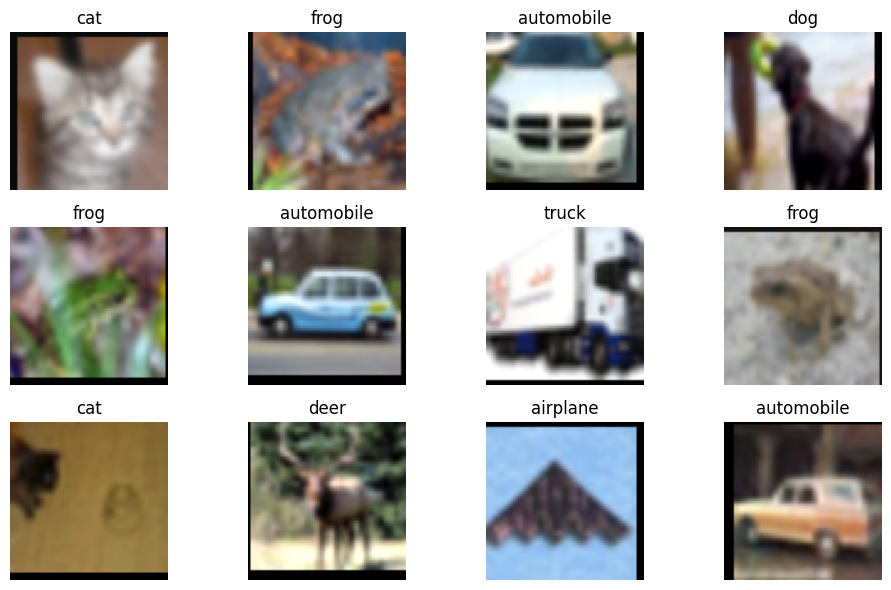

In [6]:
def denormalize(img):
    mean = torch.tensor(CIFAR10_MEAN).view(3, 1, 1)
    std = torch.tensor(CIFAR10_STD).view(3, 1, 1)
    return img * std + mean

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 6))
for i in range(12):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    plt.subplot(3, 4, i + 1)
    plt.imshow(np.clip(img, 0, 1))
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()


## CNN Model Architecture

The CNN is designed using repeated convolutional blocks to learn hierarchical image features:

**Block structure**
- Convolution (3×3) → Batch Normalization → ReLU
- Max Pooling (downsampling)
- Dropout (regularization)

**Why these components?**
- **Convolutions** extract local patterns (edges → textures → shapes).
- **Batch normalization** stabilizes training and helps gradient flow.
- **Dropout** reduces overfitting by randomly deactivating neurons during training.
- **Max pooling** reduces spatial dimensions and computation while retaining important features.


In [7]:
class CNNClassifier(nn.Module):
    def __init__(self, num_classes, dropout=0.4):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1: 3 -> 32
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),   # 64x64 -> 32x32
            nn.Dropout(0.15),

            # Block 2: 32 -> 64
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2),   # 32x32 -> 16x16
            nn.Dropout(0.25),

            # Block 3: 64 -> 128
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.MaxPool2d(2),   # 16x16 -> 8x8
            nn.Dropout(dropout),
        )

        # After 3 pool layers: IMG_SIZE=64 -> 8
        final_spatial = IMG_SIZE // 8  # 64/8 = 8
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * final_spatial * final_spatial, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = CNNClassifier(num_classes=num_classes, dropout=0.4).to(device)
model


CNNClassifier(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.15, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Dropout(p=0.25, i

In [8]:
xb, yb = next(iter(train_loader))
xb = xb.to(device)

with torch.no_grad():
    logits = model(xb)

logits.shape


torch.Size([64, 10])

## Training Setup

- **Loss function:** CrossEntropyLoss (multi-class classification)
- **Optimizer:** Adam
- **Regularization:** Dropout in the model + weight decay (L2)
- **Learning rate scheduling:** Reduce learning rate when validation accuracy plateaus
- **Model checkpointing:** Save the best model (highest validation accuracy)


In [9]:
EPOCHS = 10          # we will tune later; start with 10
LR = 1e-3
WEIGHT_DECAY = 1e-4  # L2 regularization

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2
)

best_model_path = os.path.join(OUTPUT_DIR, "best_model.pt")
best_val_acc = -1.0

best_model_path


'C:\\Users\\dubey\\Documents\\UC_GitLab\\Spring_2026_BI_Sem_1\\Project1_CNN_ImageClassification\\outputs\\best_model.pt'

In [10]:
def compute_metrics(y_true, y_pred, average="macro"):
    """
    average='macro' treats all classes equally (good for rubric reporting).
    """
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average=average, zero_division=0
    )
    acc = (np.array(y_true) == np.array(y_pred)).mean()
    return acc, precision, recall, f1

def run_one_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_true, all_pred = [], []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            logits = model(xb)
            loss = criterion(logits, yb)

            if is_train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = torch.argmax(logits, dim=1)

        all_true.extend(yb.detach().cpu().numpy().tolist())
        all_pred.extend(preds.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    acc, prec, rec, f1 = compute_metrics(all_true, all_pred, average="macro")
    return avg_loss, acc, prec, rec, f1


In [11]:
history = {
    "train_loss": [], "train_acc": [], "train_prec": [], "train_rec": [],
    "val_loss": [],   "val_acc": [],   "val_prec": [],   "val_rec": []
}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc, train_prec, train_rec, train_f1 = run_one_epoch(
        model, train_loader, criterion, optimizer=optimizer
    )
    val_loss, val_acc, val_prec, val_rec, val_f1 = run_one_epoch(
        model, val_loader, criterion, optimizer=None
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_prec"].append(train_prec)
    history["train_rec"].append(train_rec)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_prec"].append(val_prec)
    history["val_rec"].append(val_rec)

    # Scheduler uses validation accuracy
    scheduler.step(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train loss={train_loss:.4f} acc={train_acc:.4f} prec={train_prec:.4f} rec={train_rec:.4f} | "
        f"Val loss={val_loss:.4f} acc={val_acc:.4f} prec={val_prec:.4f} rec={val_rec:.4f}"
    )

print("Best validation accuracy:", best_val_acc)
print("Best model saved to:", best_model_path)


Epoch 01/10 | Train loss=1.9794 acc=0.2473 prec=0.2438 rec=0.2472 | Val loss=1.6136 acc=0.3902 prec=0.3865 rec=0.3918
Epoch 02/10 | Train loss=1.6827 acc=0.3582 prec=0.3540 rec=0.3583 | Val loss=1.4257 acc=0.5030 prec=0.5128 rec=0.5006
Epoch 03/10 | Train loss=1.5440 acc=0.4094 prec=0.4078 rec=0.4095 | Val loss=1.2705 acc=0.5518 prec=0.5511 rec=0.5519
Epoch 04/10 | Train loss=1.4601 acc=0.4417 prec=0.4449 rec=0.4417 | Val loss=1.2012 acc=0.5808 prec=0.6065 rec=0.5773
Epoch 05/10 | Train loss=1.4045 acc=0.4659 prec=0.4714 rec=0.4659 | Val loss=1.0844 acc=0.6176 prec=0.6305 rec=0.6164
Epoch 06/10 | Train loss=1.3310 acc=0.5008 prec=0.5041 rec=0.5009 | Val loss=1.0278 acc=0.6448 prec=0.6509 rec=0.6442
Epoch 07/10 | Train loss=1.2785 acc=0.5236 prec=0.5272 rec=0.5236 | Val loss=0.9602 acc=0.6636 prec=0.6753 rec=0.6606
Epoch 08/10 | Train loss=1.2239 acc=0.5484 prec=0.5499 rec=0.5484 | Val loss=0.9428 acc=0.6698 prec=0.6812 rec=0.6707
Epoch 09/10 | Train loss=1.1451 acc=0.5833 prec=0.5838 r

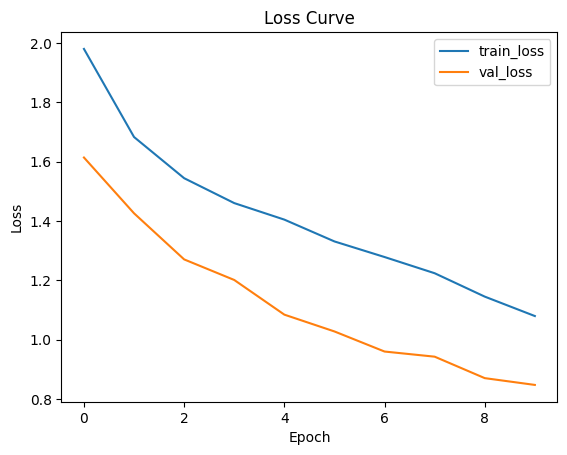

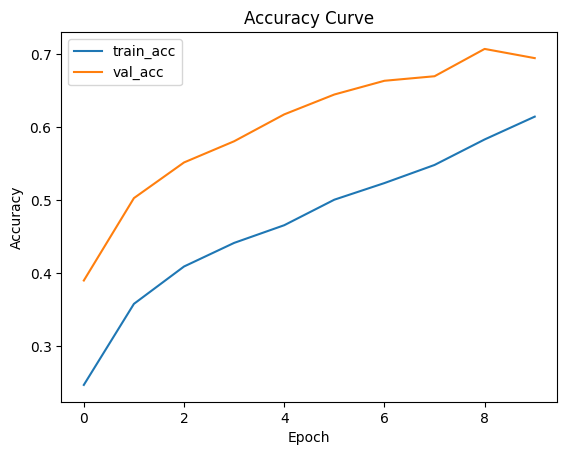

('C:\\Users\\dubey\\Documents\\UC_GitLab\\Spring_2026_BI_Sem_1\\Project1_CNN_ImageClassification\\outputs\\figures\\loss_curve.png',
 'C:\\Users\\dubey\\Documents\\UC_GitLab\\Spring_2026_BI_Sem_1\\Project1_CNN_ImageClassification\\outputs\\figures\\accuracy_curve.png')

In [12]:
# Loss curve
plt.figure()
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
loss_path = os.path.join(FIG_DIR, "loss_curve.png")
plt.savefig(loss_path, dpi=200, bbox_inches="tight")
plt.show()

# Accuracy curve
plt.figure()
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["val_acc"], label="val_acc")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
acc_path = os.path.join(FIG_DIR, "accuracy_curve.png")
plt.savefig(acc_path, dpi=200, bbox_inches="tight")
plt.show()

loss_path, acc_path


In [13]:
# Load the best saved model
best_model = CNNClassifier(num_classes=num_classes, dropout=0.4).to(device)
best_model.load_state_dict(torch.load(best_model_path, map_location=device))
best_model.eval()

all_true, all_pred = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = best_model(xb)
        preds = torch.argmax(logits, dim=1).cpu().numpy().tolist()

        all_pred.extend(preds)
        all_true.extend(yb.numpy().tolist())

test_acc, test_prec, test_rec, test_f1 = compute_metrics(all_true, all_pred, average="macro")

print(f"TEST METRICS (macro-average)")
print(f"Accuracy : {test_acc:.4f}")
print(f"Precision: {test_prec:.4f}")
print(f"Recall   : {test_rec:.4f}")
print(f"F1-score : {test_f1:.4f}")


TEST METRICS (macro-average)
Accuracy : 0.7122
Precision: 0.7109
Recall   : 0.7122
F1-score : 0.7090


In [14]:
print(classification_report(all_true, all_pred, target_names=class_names, zero_division=0))


              precision    recall  f1-score   support

    airplane       0.72      0.76      0.74      1000
  automobile       0.87      0.87      0.87      1000
        bird       0.60      0.49      0.54      1000
         cat       0.50      0.51      0.50      1000
        deer       0.72      0.54      0.62      1000
         dog       0.57      0.63      0.60      1000
        frog       0.73      0.84      0.78      1000
       horse       0.73      0.77      0.75      1000
        ship       0.86      0.84      0.85      1000
       truck       0.81      0.87      0.84      1000

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.71     10000
weighted avg       0.71      0.71      0.71     10000



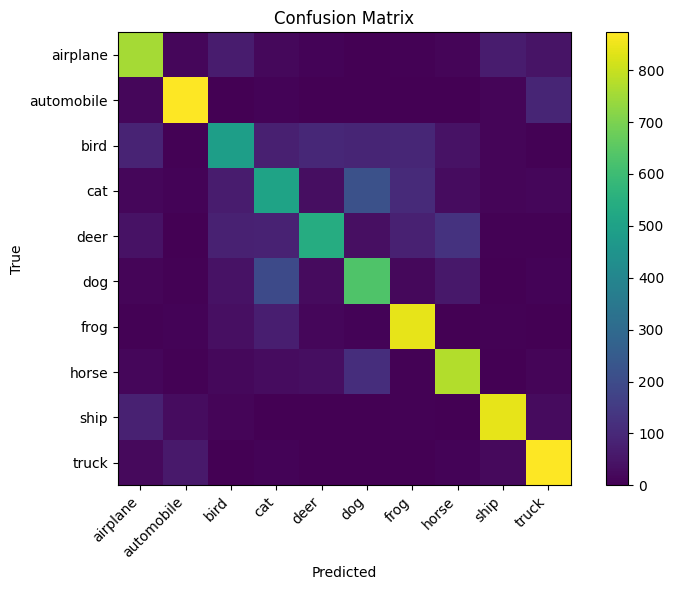

'C:\\Users\\dubey\\Documents\\UC_GitLab\\Spring_2026_BI_Sem_1\\Project1_CNN_ImageClassification\\outputs\\figures\\confusion_matrix.png'

In [15]:
cm = confusion_matrix(all_true, all_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.xticks(range(num_classes), class_names, rotation=45, ha="right")
plt.yticks(range(num_classes), class_names)
plt.tight_layout()

cm_path = os.path.join(FIG_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=200, bbox_inches="tight")
plt.show()

cm_path


In [16]:
def train_experiment(lr=1e-3, dropout=0.4, weight_decay=1e-4, epochs=3):
    exp_model = CNNClassifier(num_classes=num_classes, dropout=dropout).to(device)
    exp_criterion = nn.CrossEntropyLoss()
    exp_optimizer = optim.Adam(exp_model.parameters(), lr=lr, weight_decay=weight_decay)

    best_va = -1.0
    for ep in range(1, epochs + 1):
        tr_loss, tr_acc, tr_prec, tr_rec, tr_f1 = run_one_epoch(exp_model, train_loader, exp_criterion, optimizer=exp_optimizer)
        va_loss, va_acc, va_prec, va_rec, va_f1 = run_one_epoch(exp_model, val_loader, exp_criterion, optimizer=None)
        best_va = max(best_va, va_acc)
        print(f"  ep {ep}/{epochs} | val_acc={va_acc:.4f}")

    return best_va


In [17]:
experiments = [
    {"name": "Baseline",         "lr": 1e-3,  "dropout": 0.4, "weight_decay": 1e-4},
    {"name": "Lower LR",         "lr": 5e-4,  "dropout": 0.4, "weight_decay": 1e-4},
    {"name": "Higher Dropout",   "lr": 1e-3,  "dropout": 0.5, "weight_decay": 1e-4},
]

exp_results = []
for cfg in experiments:
    print("\nRunning:", cfg["name"], cfg)
    best_val = train_experiment(lr=cfg["lr"], dropout=cfg["dropout"], weight_decay=cfg["weight_decay"], epochs=3)
    exp_results.append({**cfg, "best_val_acc_3ep": best_val})

exp_results



Running: Baseline {'name': 'Baseline', 'lr': 0.001, 'dropout': 0.4, 'weight_decay': 0.0001}
  ep 1/3 | val_acc=0.4908
  ep 2/3 | val_acc=0.5584
  ep 3/3 | val_acc=0.5874

Running: Lower LR {'name': 'Lower LR', 'lr': 0.0005, 'dropout': 0.4, 'weight_decay': 0.0001}
  ep 1/3 | val_acc=0.5152
  ep 2/3 | val_acc=0.6054
  ep 3/3 | val_acc=0.6360

Running: Higher Dropout {'name': 'Higher Dropout', 'lr': 0.001, 'dropout': 0.5, 'weight_decay': 0.0001}
  ep 1/3 | val_acc=0.4398
  ep 2/3 | val_acc=0.5356
  ep 3/3 | val_acc=0.5718


[{'name': 'Baseline',
  'lr': 0.001,
  'dropout': 0.4,
  'weight_decay': 0.0001,
  'best_val_acc_3ep': np.float64(0.5874)},
 {'name': 'Lower LR',
  'lr': 0.0005,
  'dropout': 0.4,
  'weight_decay': 0.0001,
  'best_val_acc_3ep': np.float64(0.636)},
 {'name': 'Higher Dropout',
  'lr': 0.001,
  'dropout': 0.5,
  'weight_decay': 0.0001,
  'best_val_acc_3ep': np.float64(0.5718)}]

In [18]:
import pandas as pd

df_exp = pd.DataFrame(exp_results)[
    ["name", "lr", "dropout", "weight_decay", "best_val_acc_3ep"]
]

df_exp


,name,lr,dropout,weight_decay,best_val_acc_3ep
0,Baseline,0.0010,0.4,0.0001,0.5874
1,Lower LR,0.0005,0.4,0.0001,0.6360
2,Higher Dropout,0.0010,0.5,0.0001,0.5718
